### Read SNOWPACK Output at All Sites with HRRR-AK WY2020-WY2025

created by Cassie Lumbrazo\
last updated: May 2026\
run location: UAS linux\
python environment: **xarray**

In [46]:
# import packages 
%matplotlib inline

# plotting packages 
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns 
import matplotlib.dates as mdates

sns.set_theme()
plt.rcParams['figure.figsize'] = [12,6] #overriding size

# data packages 
import pandas as pd
import numpy as np
import xarray as xr
from datetime import datetime

import scipy
import os

In [47]:
pwd

'/home/cassie/python/repos/snow_modeling_point/sites'

# Open Data and Model Simulations

## Function for Reading SMET Files 

In [48]:
def read_smet(filepath):
    header = {}
    fields = None
    data_start = None

    # Read file and parse header
    with open(filepath, "r") as f:
        lines = f.readlines()

    for i, line in enumerate(lines):
        line = line.strip()

        # Detect fields line
        if line.startswith("fields"):
            fields = line.split("=")[1].strip().split()

        # Detect start of data
        if line == "[DATA]":
            data_start = i + 1
            break

        # Parse header key-value pairs
        if "=" in line and not line.startswith("["):
            key, value = line.split("=", 1)
            header[key.strip()] = value.strip()

    if fields is None:
        raise ValueError("No 'fields' line found in SMET header.")
    if data_start is None:
        raise ValueError("No [DATA] section found.")

    # Read data into DataFrame
    df = pd.read_csv(
        filepath,
        skiprows=data_start,
        delim_whitespace=True,
        names=fields,
        parse_dates=["timestamp"]
    )

    # Set timestamp as index
    df = df.set_index("timestamp")

    # Convert to xarray
    ds = xr.Dataset.from_dataframe(df)

    return ds, header

### Open SNOWPACK SMet Output

In [49]:
# HRRR-AK Files First 
ds_snowpack_hrrrak_ppsa, header_hrrrak_ppsa = read_smet("/home/cassie/python/models/run_snowpack/sites/ppsa/output/hrrrak_ppsa_WY2020-WY2025_base.smet")
ds_snowpack_hrrrak_tram, header_hrrrak_tram = read_smet("/home/cassie/python/models/run_snowpack/sites/tram/output/hrrrak_tram_WY2020-WY2025_base.smet")
ds_snowpack_hrrrak_heen, header_hrrrak_heen = read_smet("/home/cassie/python/models/run_snowpack/sites/heen/output/hrrrak_heen_WY2020-WY2025_base.smet")

# Met HRRR-AK Files now

ds_snowpack_met_hrrrak_ppsa, header_met_hrrrak_ppsa = read_smet("/home/cassie/python/models/run_snowpack/sites/ppsa/output/met_hrrrak_ppsa_WY2020-WY2025_base.smet") # ppsa has WY2020-WY2025
ds_snowpack_met_hrrrak_tram, header_met_hrrrak_tram = read_smet("/home/cassie/python/models/run_snowpack/sites/tram/output/met_hrrrak_tram_WY2023-WY2025_base.smet") # tram has WY2023-WY2025
ds_snowpack_met_hrrrak_heen, header_met_hrrrak_heen = read_smet("/home/cassie/python/models/run_snowpack/sites/heen/output/met_hrrrak_heen_WY2020-WY2022_base.smet") # heen doesn't have until 2025 

/tmp/ipykernel_264157/1183788903.py:33: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(
/tmp/ipykernel_264157/1183788903.py:33: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(
/tmp/ipykernel_264157/1183788903.py:33: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(
/tmp/ipykernel_264157/1183788903.py:33: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(
/tmp/ipykernel_264157/1183788903.py:33: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.

### Open Observations

In [50]:
# open observations

# HEEN 
file_heen = "/hdd/snow_hydrology/met_station/snotel/heenlatinee/heen_met_2016_2026_cleaned_v1.nc"
ds_obs_heen = xr.open_dataset(file_heen)
ds_obs_heen = ds_obs_heen.sel(time=slice("2019-10-01", "2025-09-30"))

#PPSA 
file_ppsa = "/hdd/snow_hydrology/met_station/ppsa2/pppsa_met_station_data_synoptic_2026-03-20" 
ds_obs_ppsa = xr.open_dataset(file_ppsa)
ds_obs_ppsa = ds_obs_ppsa.sel(time=slice("2019-10-01", "2025-09-30"))


# TRAM 
file_tram = "/hdd/snow_hydrology/met_station/tram/tram_met_station_data_synoptic_2026-03-20"  
ds_obs_tram = xr.open_dataset(file_tram)
ds_obs_tram = ds_obs_tram.sel(time=slice("2019-10-01", "2025-09-30"))

In [51]:
# pick colors for each site and stick to them across all plots
ppsa_color = 'darkviolet'
tram_color = 'maroon'
heen_color = 'teal'

# color hrrr-ak model 
hrrrak_color = 'tab:blue'
met_hrrrak_color = 'tab:green'
obs_color = 'tab:gray'

## Plot the sites together

Text(0, 0.5, 'snow depth (cm)')

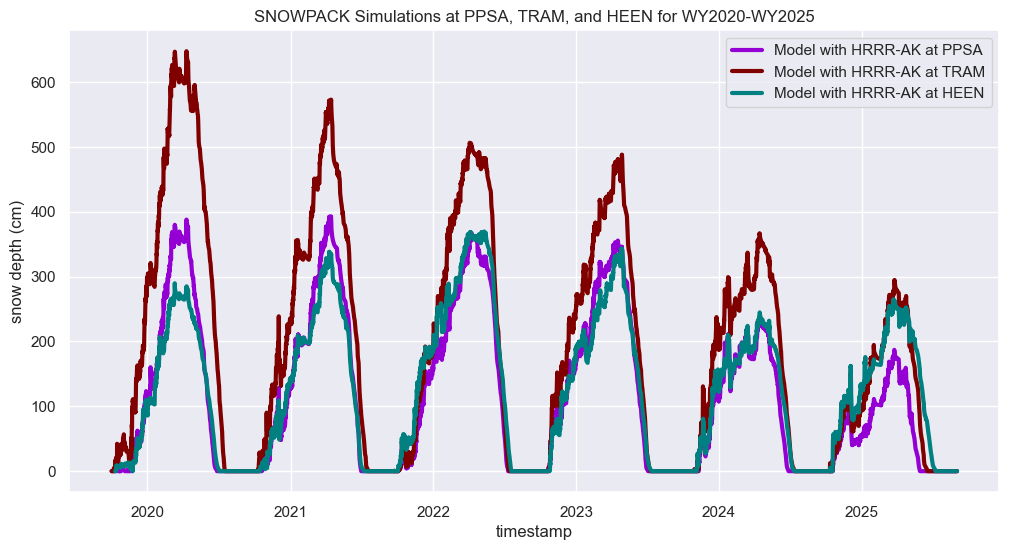

In [53]:
# plot ppsa, tram, and heen together for hrrrak
ds_snowpack_hrrrak_ppsa.HS_mod.plot(label = 'Model with HRRR-AK at PPSA', linewidth = 3, color=ppsa_color)
ds_snowpack_hrrrak_tram.HS_mod.plot(label = 'Model with HRRR-AK at TRAM', linewidth = 3, color=tram_color)
ds_snowpack_hrrrak_heen.HS_mod.plot(label = 'Model with HRRR-AK at HEEN', linewidth = 3, color=heen_color)

# plot the met hrrrak data for each site
# ds_snowpack_met_hrrrak_ppsa.HS_mod.plot(label = 'Model with HRRR-AK Met at PPSA', linewidth = 3, color=met_hrrrak_color, linestyle='--')
# ds_snowpack_met_hrrrak_tram.HS_mod.plot(label = 'Model with HRRR-AK Met at TRAM', linewidth = 3, color=met_hrrrak_color, linestyle='--')
# ds_snowpack_met_hrrrak_heen.HS_mod.plot(label = 'Model with HRRR-AK Met at HEEN', linewidth = 3, color=met_hrrrak_color, linestyle='--')

# plot observations 
# ds_obs_heen.hs.plot(label = 'HEEN Obs', linewidth = 3, color=heen_color, linestyle='--')
# ds_obs_tram.hs.plot(label = 'TRAM Obs', linewidth = 3, color=tram_color, linestyle='--')
# ds_obs_ppsa.hs.plot(label = 'PPSA Obs', linewidth = 3, color=ppsa_color, linestyle='--')


plt.title('SNOWPACK Simulations at PPSA, TRAM, and HEEN for WY2020-WY2025')
plt.legend(loc = 'upper right')

# plt.ylim([-10, 300])

plt.ylabel('snow depth (cm)')

### SWE

Text(0, 0.5, 'SWE (mm)')

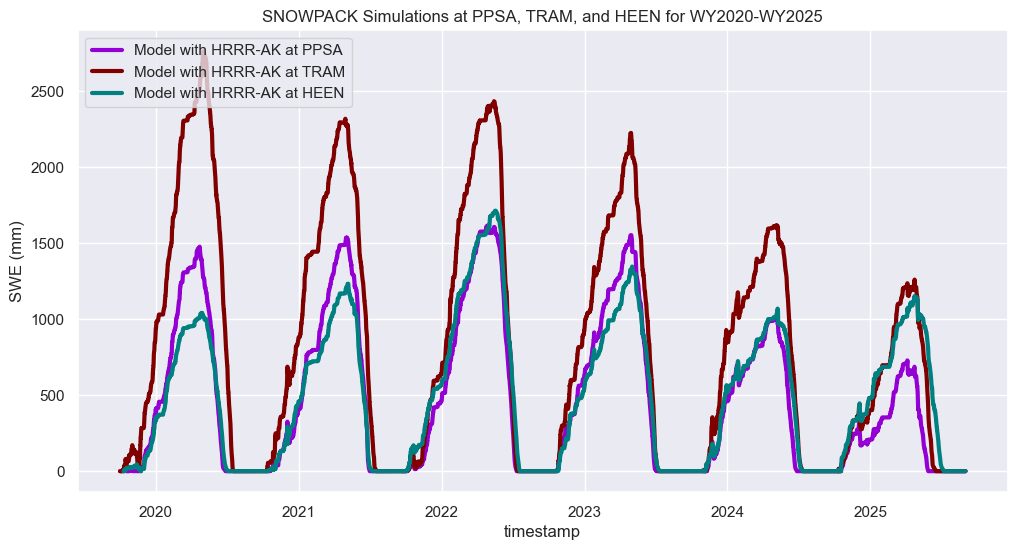

In [54]:
# plot ppsa, tram, and heen together for hrrrak
ds_snowpack_hrrrak_ppsa.SWE.plot(label = 'Model with HRRR-AK at PPSA', linewidth = 3, color=ppsa_color)
ds_snowpack_hrrrak_tram.SWE.plot(label = 'Model with HRRR-AK at TRAM', linewidth = 3, color=tram_color)
ds_snowpack_hrrrak_heen.SWE.plot(label = 'Model with HRRR-AK at HEEN', linewidth = 3, color=heen_color)


plt.title('SNOWPACK Simulations at PPSA, TRAM, and HEEN for WY2020-WY2025')
plt.legend(loc = 'upper left')

plt.ylabel('SWE (mm)')

## Subplot for each site 

Temporary until I fix the snow depth more...

In [55]:
ds_obs_ppsa = ds_obs_ppsa.sel(time=slice("2020-01-10", "2025-09-30"))

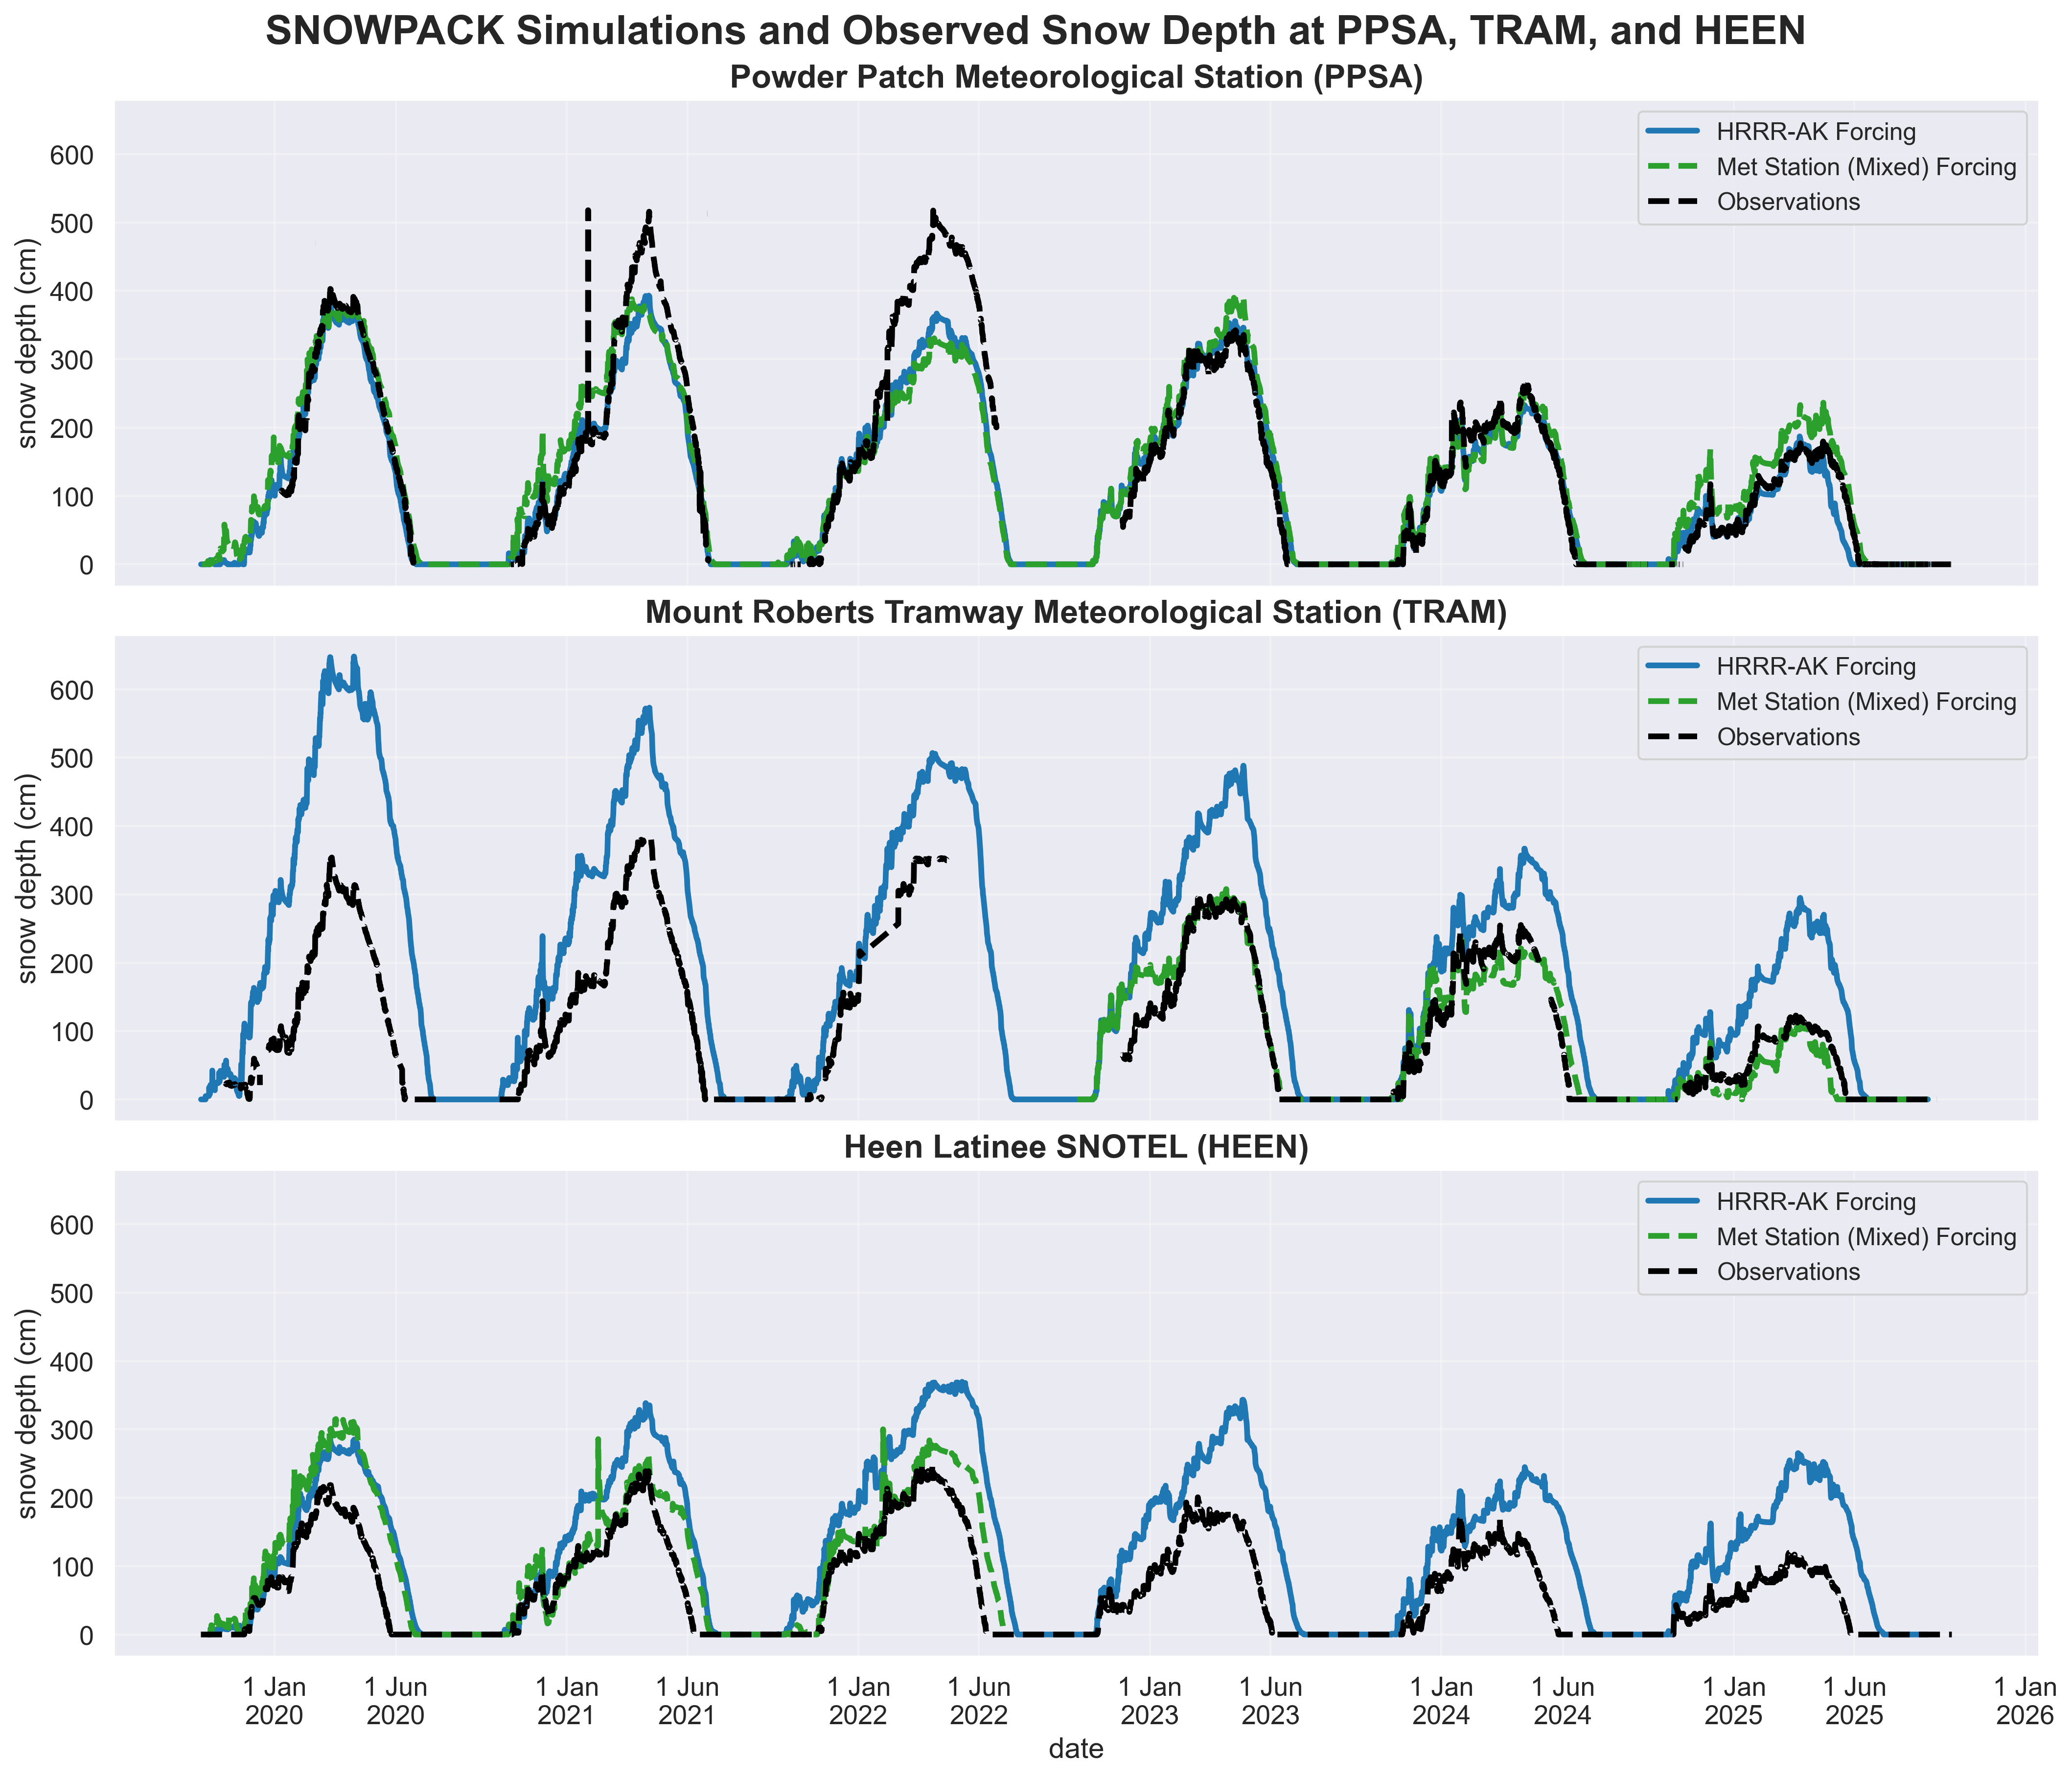

In [56]:
# ============================================================
# Adjustable manuscript-style plotting parameters
# ============================================================

# Figure
fig_width = 14
fig_height = 12
dpi = 300

# Fonts
title_fontsize = 20
subplot_title_fontsize = 16
axis_label_fontsize = 14
tick_fontsize = 13
legend_fontsize = 12

# Lines
model_linewidth = 2.8
obs_linewidth = 2.5

# Tick sizes
major_tick_length = 6
major_tick_width = 1.2

# Axis linewidth
spine_width = 1.2

# ============================================================
# Colors
# ============================================================

hrrrak_color = 'tab:blue'
met_hrrrak_color = 'tab:green'
# obs_color = 'tab:gray'
obs_color = 'black'

# ============================================================
# Create figure and subplots
# ============================================================

fig, axes = plt.subplots(
    nrows=3,
    ncols=1,
    figsize=(fig_width, fig_height),
    dpi=dpi,
    sharex=True,
    sharey=True,
    constrained_layout=True
)

# ============================================================
# Site configuration
# ============================================================

sites = [
    {
        'ax': axes[0],
        'site_name': 'Powder Patch Meteorological Station (PPSA)',
        'hrrr_ds': ds_snowpack_hrrrak_ppsa,
        'met_ds': ds_snowpack_met_hrrrak_ppsa,
        'obs_ds': ds_obs_ppsa
    },
    {
        'ax': axes[1],
        'site_name': 'Mount Roberts Tramway Meteorological Station (TRAM)',
        'hrrr_ds': ds_snowpack_hrrrak_tram,
        'met_ds': ds_snowpack_met_hrrrak_tram,
        'obs_ds': ds_obs_tram
    },
    {
        'ax': axes[2],
        'site_name': 'Heen Latinee SNOTEL (HEEN)',
        'hrrr_ds': ds_snowpack_hrrrak_heen,
        'met_ds': ds_snowpack_met_hrrrak_heen,
        'obs_ds': ds_obs_heen
    }
]

# ============================================================
# Plot each site
# ============================================================

for site in sites:

    ax = site['ax']

    # HRRR-AK forcing simulation
    site['hrrr_ds'].HS_mod.plot(
        ax=ax,
        color=hrrrak_color,
        linewidth=model_linewidth,
        label='HRRR-AK Forcing'
    )

    # Mixed met + HRRR-AK forcing simulation
    site['met_ds'].HS_mod.plot(
        ax=ax,
        color=met_hrrrak_color,
        linewidth=model_linewidth,
        linestyle='--',
        label='Met Station (Mixed) Forcing'
    )

    # Observations
    site['obs_ds'].hs.plot(
        ax=ax,
        color=obs_color,
        # linewidth=obs_linewidth,
        # linestyle=':',
        # marker='o',
        # # no line between the markers, just points
        # linestyle='None',
        # markersize=1,
        linewidth=model_linewidth,
        linestyle='--',
        label='Observations'
    )

    # --------------------------------------------------------
    # Subplot formatting
    # --------------------------------------------------------

    ax.set_title(
        site['site_name'],
        fontsize=subplot_title_fontsize,
        fontweight='bold'
    )

    ax.set_ylabel(
        'snow depth (cm)',
        fontsize=axis_label_fontsize
    )

    ax.tick_params(
        axis='both',
        which='major',
        labelsize=tick_fontsize,
        length=major_tick_length,
        width=major_tick_width
    )

    # Spine thickness
    for spine in ax.spines.values():
        spine.set_linewidth(spine_width)

    # Legend
    ax.legend(
        fontsize=legend_fontsize,
        loc='upper right',
        frameon=True
    )

    # Optional grid
    ax.grid(alpha=0.3)

# ============================================================
# Shared x-axis formatting
# ============================================================

# remove the x-axis labels for the top two subplots
for ax in axes[:-1]:
    ax.set_xlabel('')  # remove x-axis label

axes[-1].set_xlabel(
    'date',
    fontsize=axis_label_fontsize
)

# # Nice date formatting
# axes[-1].xaxis.set_major_locator(mdates.YearLocator())
# axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))


# ============================================================
# Replace your current x-axis formatting section with this
# ============================================================

# Major ticks:
# January 1, May 1, November 1 each year
# major_locator = mdates.MonthLocator(bymonth=[1, 5, 11])
major_locator = mdates.MonthLocator(bymonth=[1, 6])

# Format example:
# 1 January 2022
major_formatter = mdates.DateFormatter('%-d %b\n%Y')

for ax in axes:

    ax.xaxis.set_major_locator(major_locator)
    ax.xaxis.set_major_formatter(major_formatter)

    # # Rotate labels for readability
    # plt.setp(
    #     ax.get_xticklabels(),
    #     rotation=30,
    #     ha='right'
    # )

# ============================================================
# Optional:
# Reduce clutter even more with smaller font
# ============================================================

for ax in axes:
    ax.tick_params(
        axis='x',
        labelsize=tick_fontsize
    )

# ============================================================
# Optional y-axis limits
# ============================================================

# Uncomment and adjust if desired
# axes[0].set_ylim(0, 350)

# ============================================================
# Figure title
# ============================================================

fig.suptitle(
    'SNOWPACK Simulations and Observed Snow Depth at PPSA, TRAM, and HEEN',
    fontsize=title_fontsize,
    fontweight='bold'
)

# ============================================================
# Save figure
# ============================================================

# Recommended formats for manuscripts
# plt.savefig('snowpack_comparison.png', dpi=300, bbox_inches='tight')
# plt.savefig('snowpack_comparison.pdf', bbox_inches='tight')

plt.show()

## Cut to just three years each

In [57]:
ds_obs_heen = ds_obs_heen.sel(time=slice("2019-09-01", "2022-09-30"))
ds_obs_ppsa = ds_obs_ppsa.sel(time=slice("2022-09-01", "2025-09-30"))
ds_obs_tram = ds_obs_tram.sel(time=slice("2022-09-01", "2025-09-30"))

In [58]:
ds_obs_heen

<xarray.Dataset> Size: 2MB
Dimensions:           (time: 23506)
Coordinates:
  * time              (time) datetime64[ns] 188kB 2019-10-01 ... 2022-09-30T2...
Data variables:
    swe               (time) float64 188kB ...
    temp              (time) float64 188kB ...
    hs                (time) float64 188kB ...
    rh                (time) float64 188kB ...
    precip_accum      (time) float64 188kB ...
    wind              (time) float64 188kB ...
    wind_dir          (time) float64 188kB ...
    pressure          (time) float64 188kB ...
    precip_rate       (time) float64 188kB ...
    precip_accum_1hr  (time) float64 188kB ...

And different code entirely, 

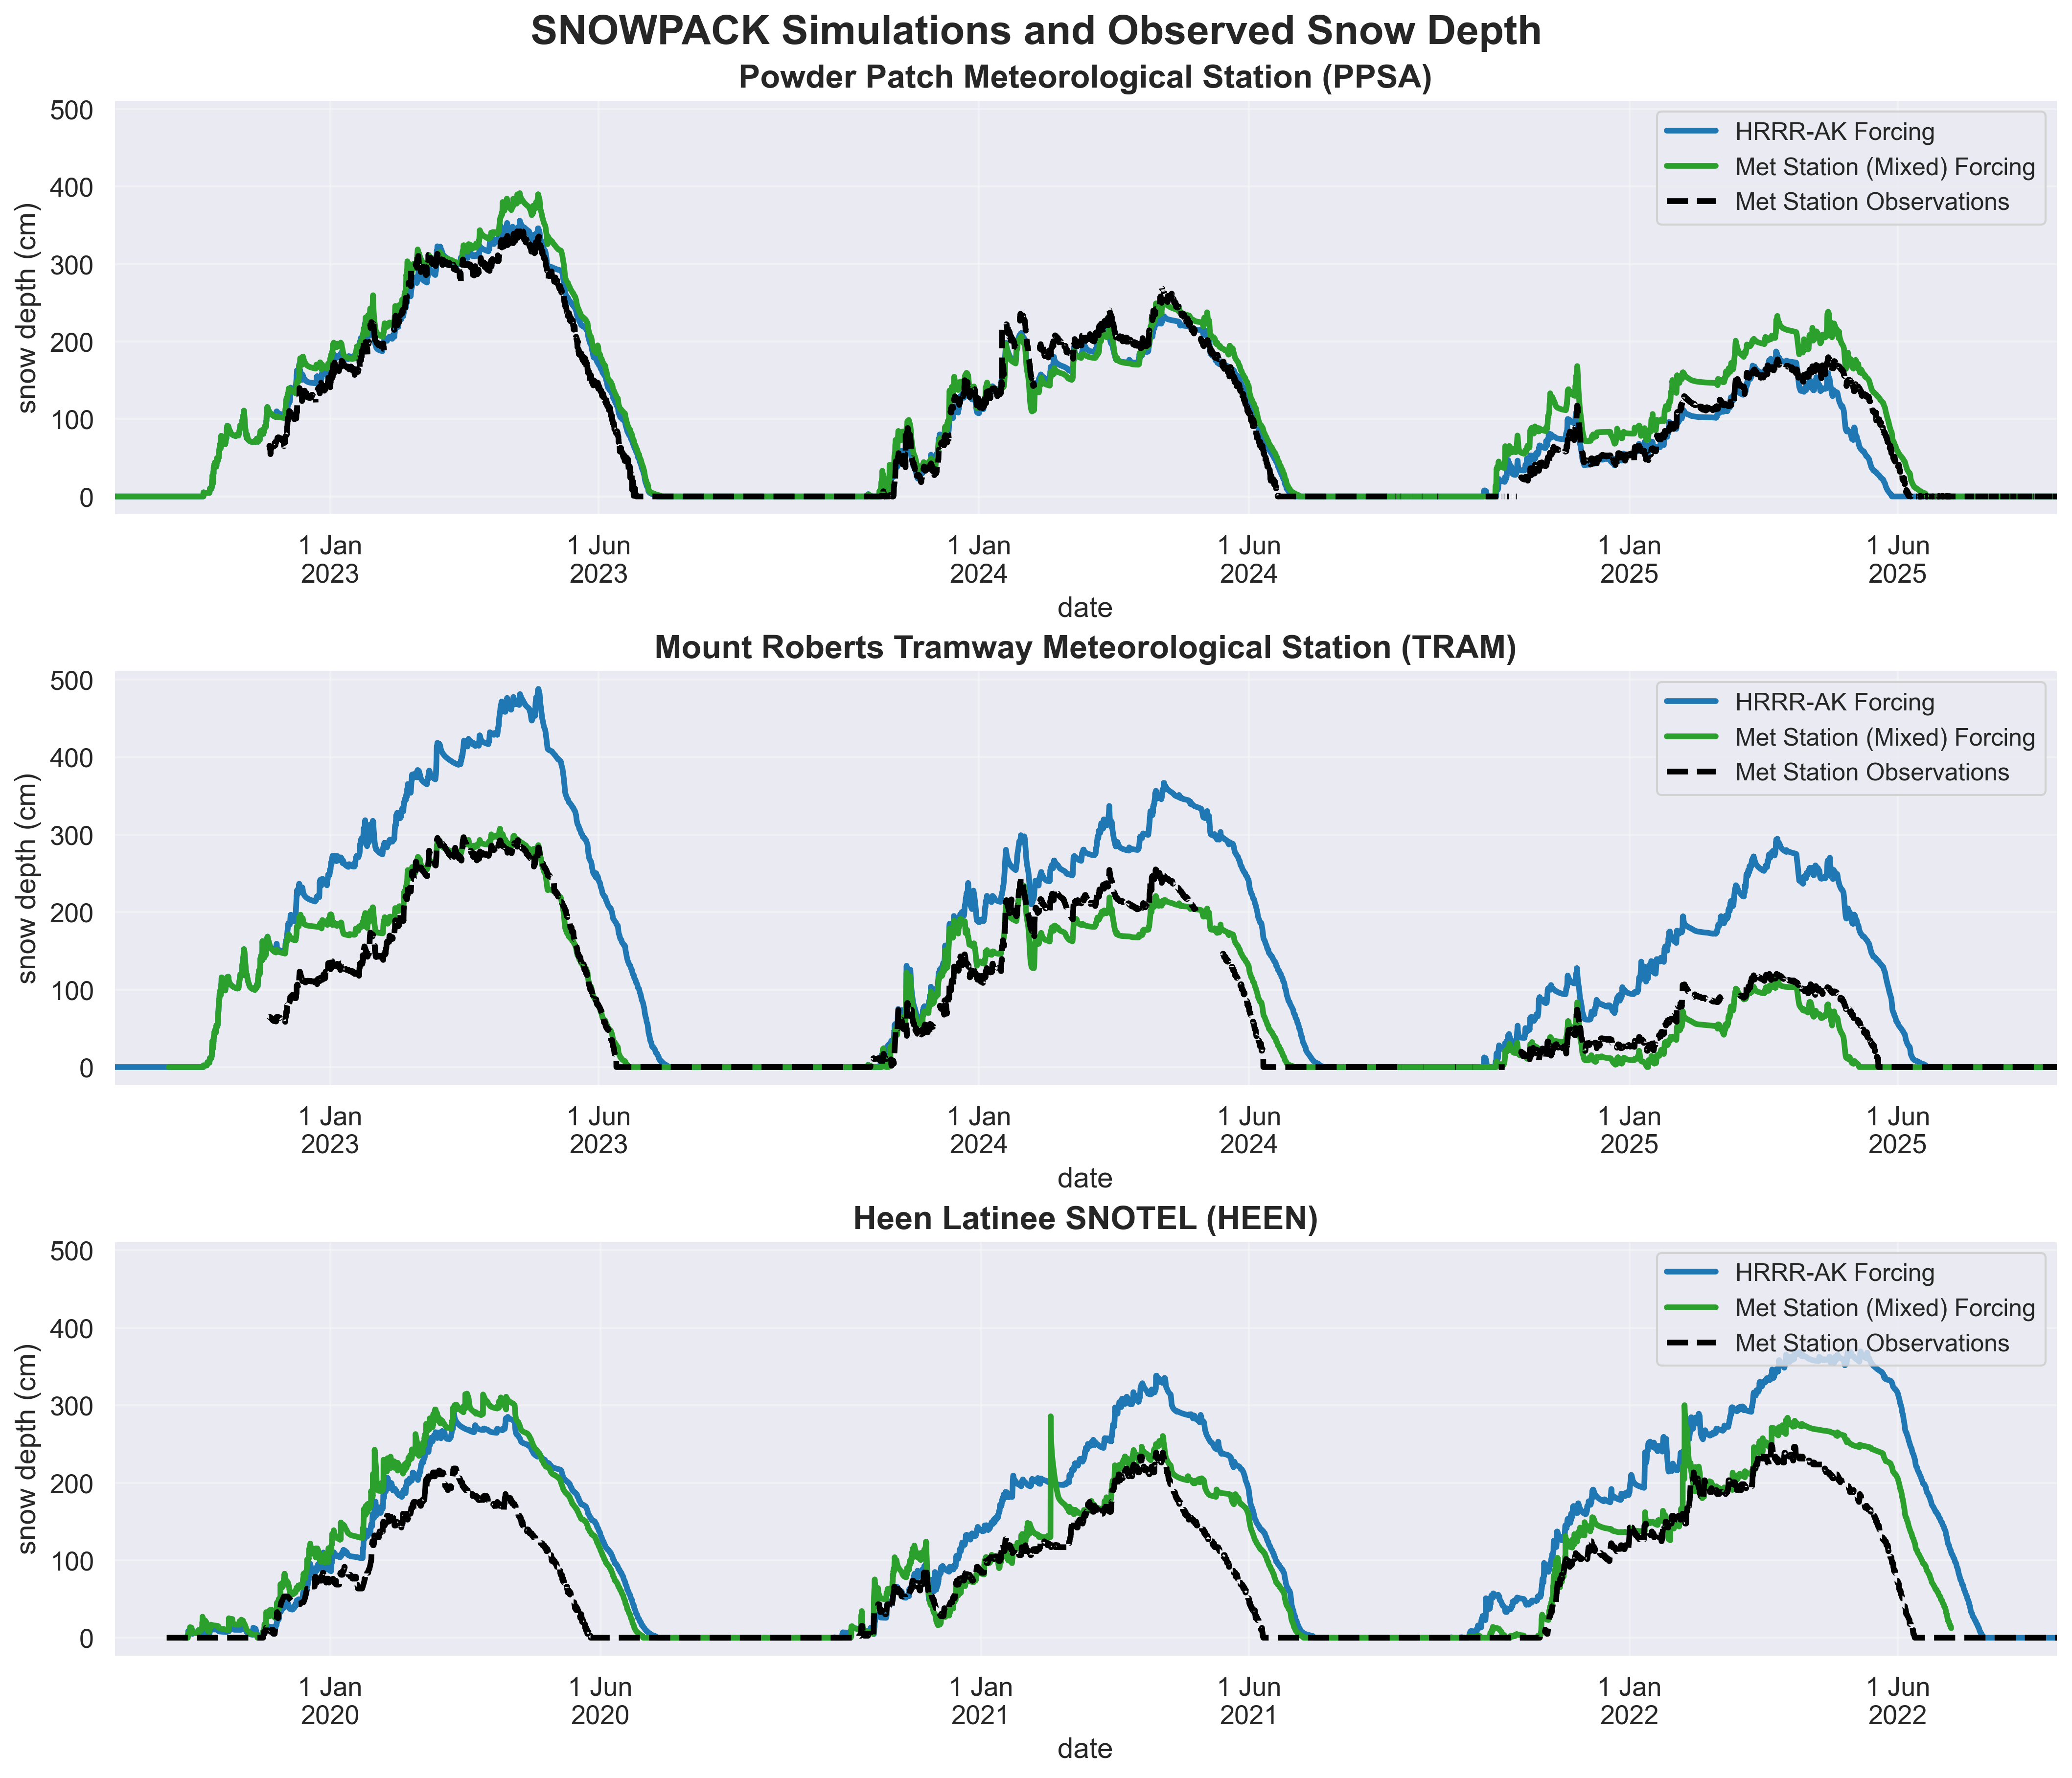

In [59]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd

# ============================================================
# Select periods
# ============================================================

# HEEN -> WY2020-WY2022
heen_start = "2019-09-01"
heen_end   = "2022-08-30"

# PPSA + TRAM -> WY2023-WY2025
modern_start = "2022-09-01"
modern_end   = "2025-08-30"

# ------------------------------------------------------------
# Observations
# ------------------------------------------------------------

ds_obs_heen_plot = ds_obs_heen.sel(time=slice(heen_start, heen_end))
ds_obs_ppsa_plot = ds_obs_ppsa.sel(time=slice(modern_start, modern_end))
ds_obs_tram_plot = ds_obs_tram.sel(time=slice(modern_start, modern_end))

# ------------------------------------------------------------
# HRRR-AK simulations
# ------------------------------------------------------------

ds_snowpack_hrrrak_heen_plot = ds_snowpack_hrrrak_heen.sel(timestamp=slice(heen_start, heen_end))
ds_snowpack_hrrrak_ppsa_plot = ds_snowpack_hrrrak_ppsa.sel(timestamp=slice(modern_start, modern_end))
ds_snowpack_hrrrak_tram_plot = ds_snowpack_hrrrak_tram.sel(timestamp=slice(modern_start, modern_end))

# ------------------------------------------------------------
# Mixed met forcing simulations
# ------------------------------------------------------------

ds_snowpack_met_hrrrak_heen_plot = ds_snowpack_met_hrrrak_heen.sel(timestamp=slice(heen_start, heen_end))
ds_snowpack_met_hrrrak_ppsa_plot = ds_snowpack_met_hrrrak_ppsa.sel(timestamp=slice(modern_start, modern_end))
ds_snowpack_met_hrrrak_tram_plot = ds_snowpack_met_hrrrak_tram.sel(timestamp=slice(modern_start, modern_end))

# ============================================================
# Adjustable manuscript-style plotting parameters
# ============================================================

fig_width = 14
fig_height = 12
dpi = 300

title_fontsize = 20
subplot_title_fontsize = 16
axis_label_fontsize = 14
tick_fontsize = 13
legend_fontsize = 12

model_linewidth = 2.8
obs_linewidth = 2.5

major_tick_length = 6
major_tick_width = 1.2

spine_width = 1.2

# ============================================================
# Colors
# ============================================================

hrrrak_color = 'tab:blue'
met_hrrrak_color = 'tab:green'
obs_color = 'black'

# ============================================================
# Create figure
# ============================================================

fig = plt.figure(figsize=(fig_width, fig_height), dpi=dpi, constrained_layout=True)

# ------------------------------------------------------------
# Create axes manually
# ------------------------------------------------------------

ax1 = plt.subplot(3, 1, 1)
ax2 = plt.subplot(3, 1, 2, sharey=ax1)
ax3 = plt.subplot(3, 1, 3, sharey=ax1)

# ============================================================
# Site configuration
# ============================================================

sites = [
    {
        'ax': ax1,
        'site_name': 'Powder Patch Meteorological Station (PPSA)',
        'hrrr_ds': ds_snowpack_hrrrak_ppsa_plot,
        'met_ds': ds_snowpack_met_hrrrak_ppsa_plot,
        'obs_ds': ds_obs_ppsa_plot,
        'xmin': modern_start,
        'xmax': modern_end
    },
    {
        'ax': ax2,
        'site_name': 'Mount Roberts Tramway Meteorological Station (TRAM)',
        'hrrr_ds': ds_snowpack_hrrrak_tram_plot,
        'met_ds': ds_snowpack_met_hrrrak_tram_plot,
        'obs_ds': ds_obs_tram_plot,
        'xmin': modern_start,
        'xmax': modern_end
    },
    {
        'ax': ax3,
        'site_name': 'Heen Latinee SNOTEL (HEEN)',
        'hrrr_ds': ds_snowpack_hrrrak_heen_plot,
        'met_ds': ds_snowpack_met_hrrrak_heen_plot,
        'obs_ds': ds_obs_heen_plot,
        'xmin': heen_start,
        'xmax': heen_end
    }
]

# ============================================================
# Plot each site
# ============================================================

for site in sites:
    ax = site['ax']

    # --------------------------------------------------------
    # HRRR-AK forcing simulation
    # --------------------------------------------------------

    site['hrrr_ds'].HS_mod.plot(
        ax=ax,
        color=hrrrak_color,
        linewidth=model_linewidth,
        label='HRRR-AK Forcing'
    )

    # --------------------------------------------------------
    # Mixed met forcing simulation
    # --------------------------------------------------------

    site['met_ds'].HS_mod.plot(
        ax=ax,
        color=met_hrrrak_color,
        linewidth=model_linewidth,
        label='Met Station (Mixed) Forcing'
    )

    # --------------------------------------------------------
    # Observations
    # --------------------------------------------------------

    site['obs_ds'].hs.plot(
        ax=ax,
        color=obs_color,
        # linestyle='None',
        # marker='o',
        # markersize=1,
        linestyle='--',
        linewidth=model_linewidth,
        label='Met Station Observations'
    )

    # --------------------------------------------------------
    # Axis limits
    # --------------------------------------------------------

    ax.set_xlim(pd.Timestamp(site['xmin']), pd.Timestamp(site['xmax']))

    # --------------------------------------------------------
    # Titles and labels
    # --------------------------------------------------------

    ax.set_title(
        site['site_name'],
        fontsize=subplot_title_fontsize,
        fontweight='bold'
    )

    ax.set_ylabel(
        'snow depth (cm)',
        fontsize=axis_label_fontsize
    )

    # --------------------------------------------------------
    # Tick formatting
    # --------------------------------------------------------

    ax.tick_params(
        axis='both',
        which='major',
        labelsize=tick_fontsize,
        length=major_tick_length,
        width=major_tick_width
    )

    # --------------------------------------------------------
    # Spine thickness
    # --------------------------------------------------------

    for spine in ax.spines.values():
        spine.set_linewidth(spine_width)

    # --------------------------------------------------------
    # Legend
    # --------------------------------------------------------

    ax.legend(
        fontsize=legend_fontsize,
        loc='upper right',
        frameon=True
    )

    # --------------------------------------------------------
    # Grid
    # --------------------------------------------------------

    ax.grid(alpha=0.3)

# ============================================================
# X-axis formatting
# ============================================================

# Major ticks
for ax in [ax1, ax2, ax3]:
    ax.set_xlabel('date', fontsize=axis_label_fontsize)
    # major_locator = mdates.MonthLocator(bymonth=[1, 6, 10])  # Major ticks: Jan 1, May 1, Nov 1
    major_locator = mdates.MonthLocator(bymonth=[1, 6])  # Major ticks: Jan 1, May 1, Nov 1
    major_formatter = mdates.DateFormatter('%-d %b\n%Y')  # Date format

    ax.xaxis.set_major_locator(major_locator)
    ax.xaxis.set_major_formatter(major_formatter)

    # Force tick labels visible on ALL subplots
    ax.tick_params(axis='x', which='major', labelbottom=True, labelsize=tick_fontsize)

# ============================================================
# Shared y-axis limits
# ============================================================

# Optional
# ax1.set_ylim(0, 350)

# ============================================================
# Figure title
# ============================================================

fig.suptitle(
    'SNOWPACK Simulations and Observed Snow Depth',
    fontsize=title_fontsize,
    fontweight='bold'
)

# ============================================================
# Save figure
# ============================================================

# plt.savefig('snowpack_comparison_manuscript.png', dpi=300, bbox_inches='tight')
# plt.savefig('snowpack_comparison_manuscript.pdf', bbox_inches='tight')

plt.show()


Same one, except with shared x-axis on ax1 and ax2

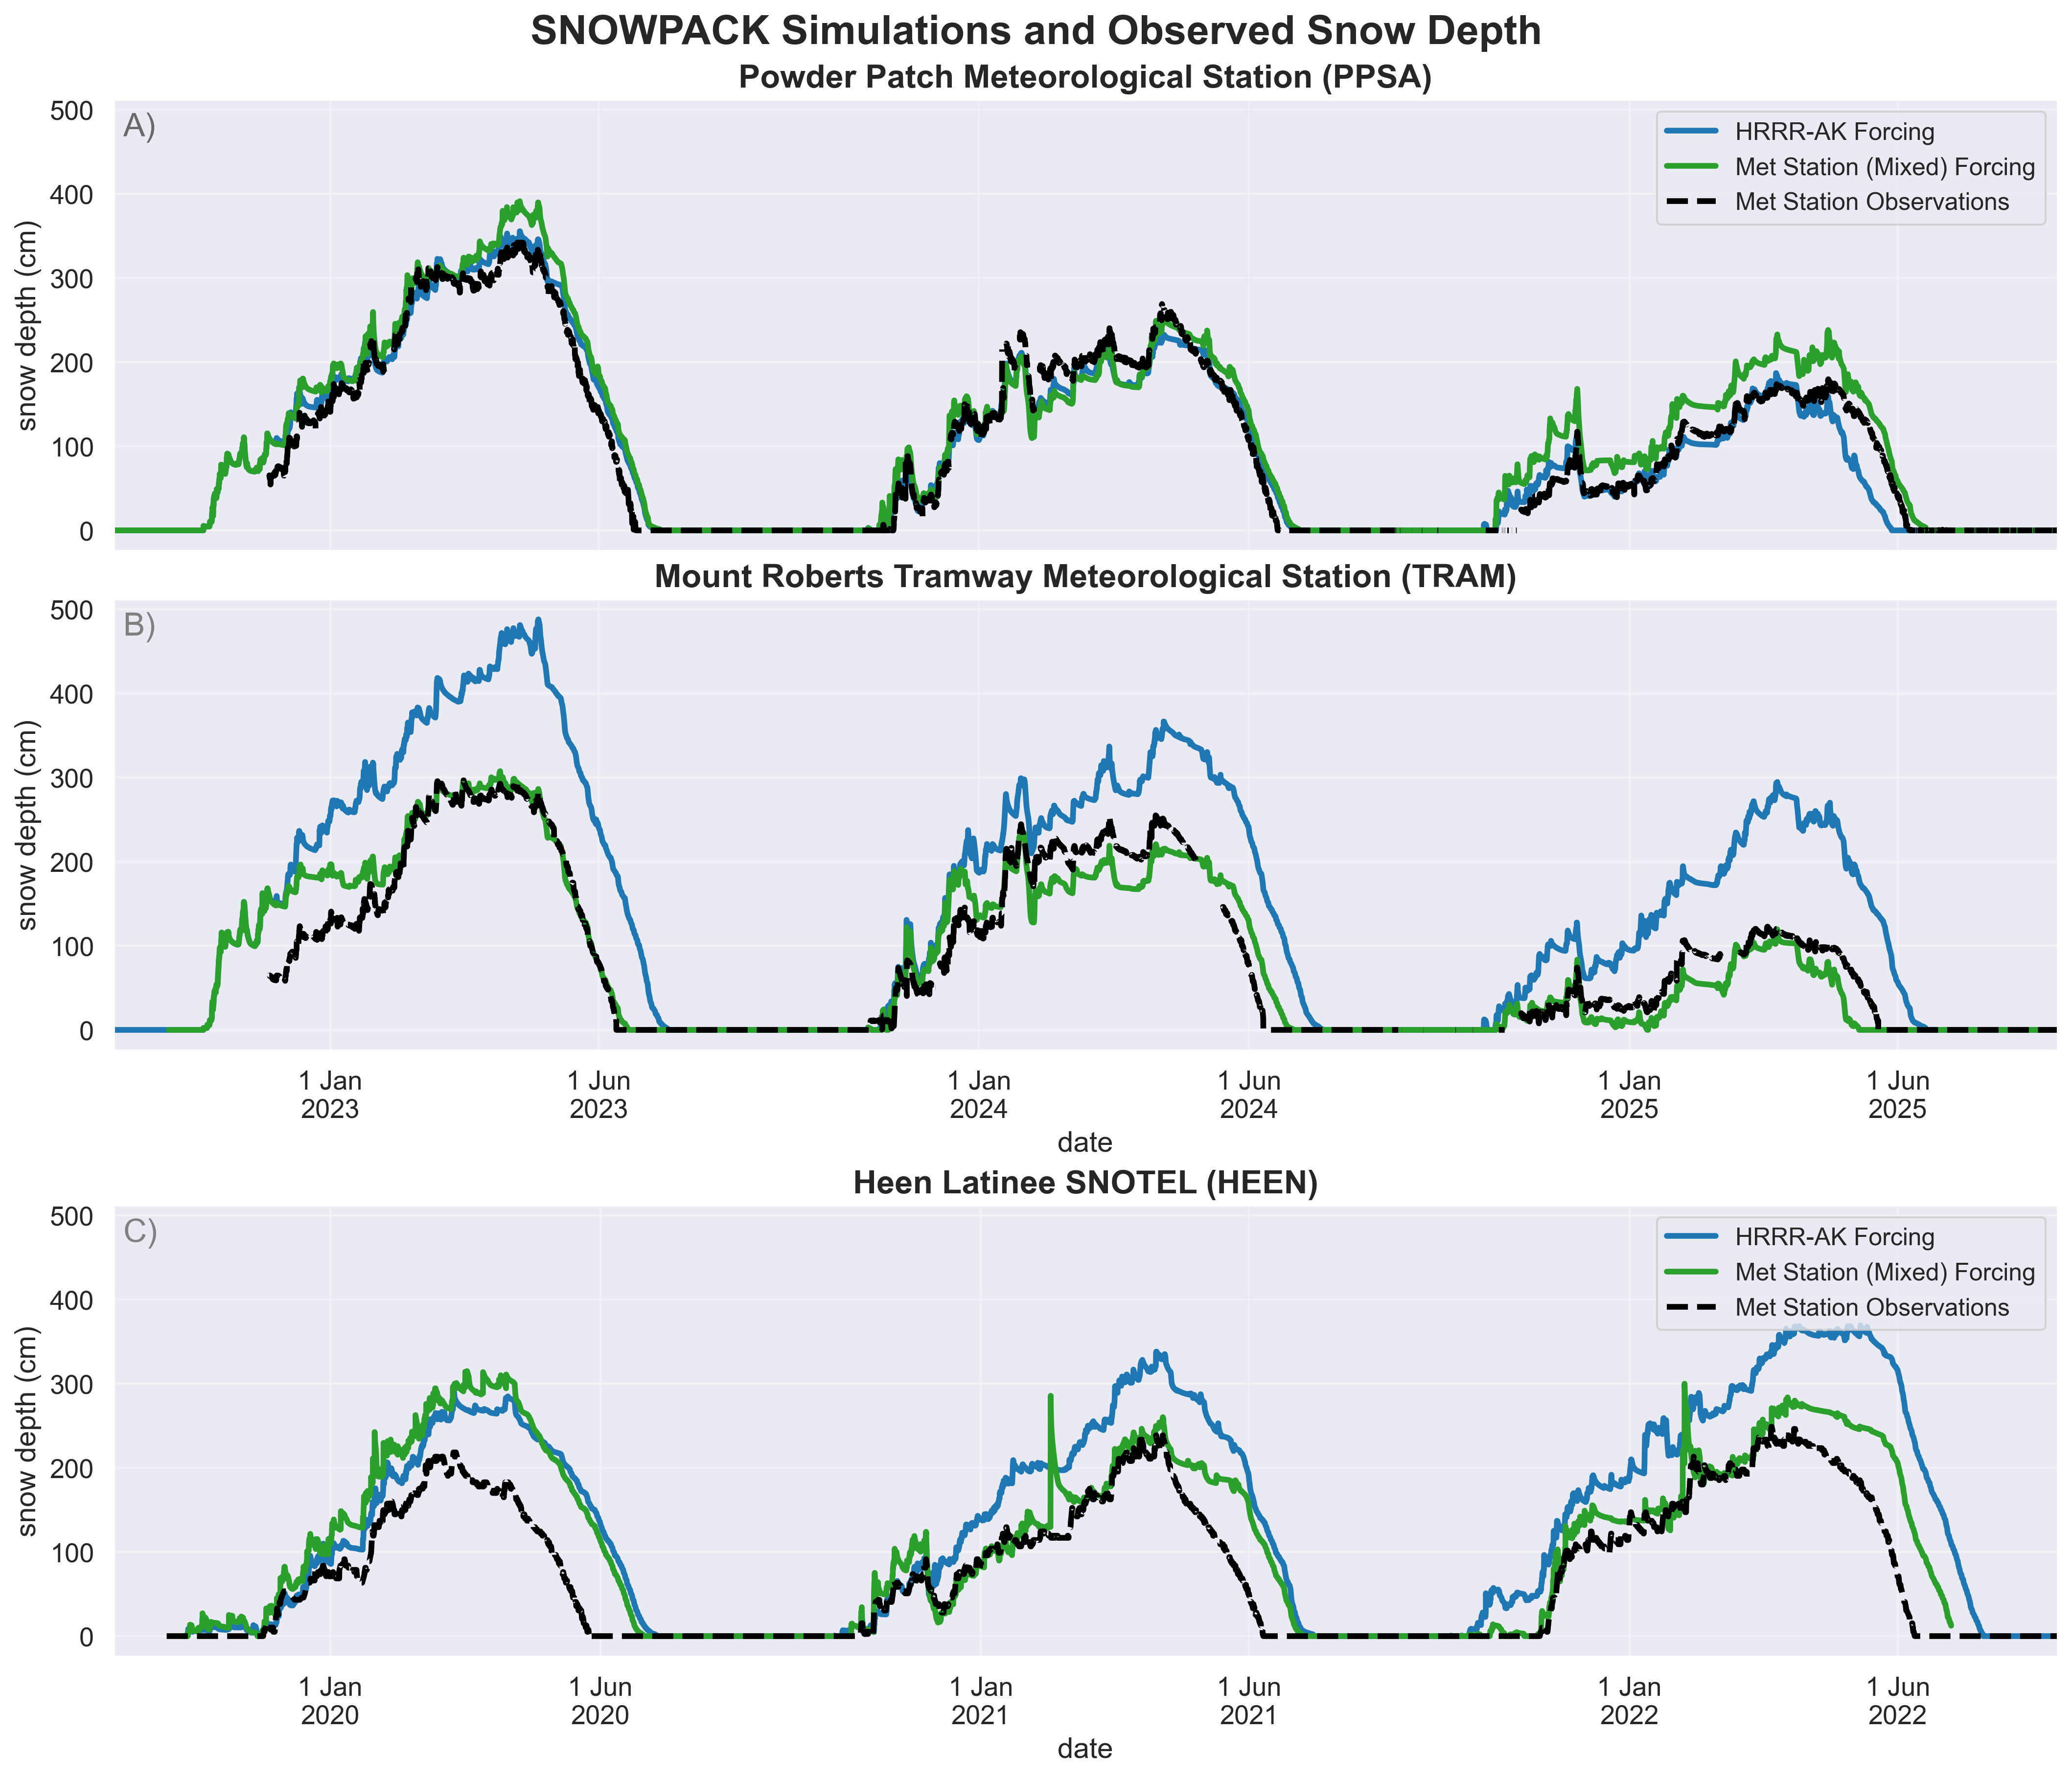

In [60]:
# ============================================================
# Select periods
# ============================================================

# HEEN -> WY2020-WY2022
heen_start = "2019-09-01"
heen_end   = "2022-08-30"

# PPSA + TRAM -> WY2023-WY2025
modern_start = "2022-09-01"
modern_end   = "2025-08-30"

# ------------------------------------------------------------
# Observations
# ------------------------------------------------------------

ds_obs_heen_plot = ds_obs_heen.sel(time=slice(heen_start, heen_end))
ds_obs_ppsa_plot = ds_obs_ppsa.sel(time=slice(modern_start, modern_end))
ds_obs_tram_plot = ds_obs_tram.sel(time=slice(modern_start, modern_end))

# ------------------------------------------------------------
# HRRR-AK simulations
# ------------------------------------------------------------

ds_snowpack_hrrrak_heen_plot = ds_snowpack_hrrrak_heen.sel(timestamp=slice(heen_start, heen_end))
ds_snowpack_hrrrak_ppsa_plot = ds_snowpack_hrrrak_ppsa.sel(timestamp=slice(modern_start, modern_end))
ds_snowpack_hrrrak_tram_plot = ds_snowpack_hrrrak_tram.sel(timestamp=slice(modern_start, modern_end))

# ------------------------------------------------------------
# Mixed met forcing simulations
# ------------------------------------------------------------

ds_snowpack_met_hrrrak_heen_plot = ds_snowpack_met_hrrrak_heen.sel(timestamp=slice(heen_start, heen_end))
ds_snowpack_met_hrrrak_ppsa_plot = ds_snowpack_met_hrrrak_ppsa.sel(timestamp=slice(modern_start, modern_end))
ds_snowpack_met_hrrrak_tram_plot = ds_snowpack_met_hrrrak_tram.sel(timestamp=slice(modern_start, modern_end))

# ============================================================
# Adjustable manuscript-style plotting parameters
# ============================================================

fig_width = 14
fig_height = 12
dpi = 300

title_fontsize = 20
subplot_title_fontsize = 16
axis_label_fontsize = 14
tick_fontsize = 13
legend_fontsize = 12

model_linewidth = 2.8
obs_linewidth = 2.5

major_tick_length = 6
major_tick_width = 1.2

spine_width = 1.2

# ============================================================
# Colors
# ============================================================

hrrrak_color = 'tab:blue'
met_hrrrak_color = 'tab:green'
obs_color = 'black'

# ============================================================
# Create figure
# ============================================================

fig = plt.figure(figsize=(fig_width, fig_height), dpi=dpi, constrained_layout=True)

# ------------------------------------------------------------
# Create axes manually
# ------------------------------------------------------------

ax1 = plt.subplot(3, 1, 1)
ax2 = plt.subplot(3, 1, 2, sharex=ax1, sharey=ax1)
ax3 = plt.subplot(3, 1, 3, sharey=ax1)

# ============================================================
# Site configuration
# ============================================================

sites = [
    {
        'ax': ax1,
        'site_name': 'Powder Patch Meteorological Station (PPSA)',
        'hrrr_ds': ds_snowpack_hrrrak_ppsa_plot,
        'met_ds': ds_snowpack_met_hrrrak_ppsa_plot,
        'obs_ds': ds_obs_ppsa_plot,
        'xmin': modern_start,
        'xmax': modern_end
    },
    {
        'ax': ax2,
        'site_name': 'Mount Roberts Tramway Meteorological Station (TRAM)',
        'hrrr_ds': ds_snowpack_hrrrak_tram_plot,
        'met_ds': ds_snowpack_met_hrrrak_tram_plot,
        'obs_ds': ds_obs_tram_plot,
        'xmin': modern_start,
        'xmax': modern_end
    },
    {
        'ax': ax3,
        'site_name': 'Heen Latinee SNOTEL (HEEN)',
        'hrrr_ds': ds_snowpack_hrrrak_heen_plot,
        'met_ds': ds_snowpack_met_hrrrak_heen_plot,
        'obs_ds': ds_obs_heen_plot,
        'xmin': heen_start,
        'xmax': heen_end
    }
]

# ============================================================
# Plot each site
# ============================================================

for site in sites:
    ax = site['ax']

    # --------------------------------------------------------
    # HRRR-AK forcing simulation
    # --------------------------------------------------------

    site['hrrr_ds'].HS_mod.plot(
        ax=ax,
        color=hrrrak_color,
        linewidth=model_linewidth,
        label='HRRR-AK Forcing'
    )

    # --------------------------------------------------------
    # Mixed met forcing simulation
    # --------------------------------------------------------

    site['met_ds'].HS_mod.plot(
        ax=ax,
        color=met_hrrrak_color,
        linewidth=model_linewidth,
        label='Met Station (Mixed) Forcing'
    )

    # --------------------------------------------------------
    # Observations
    # --------------------------------------------------------

    site['obs_ds'].hs.plot(
        ax=ax,
        color=obs_color,
        # linestyle='None',
        # marker='o',
        # markersize=1,
        linestyle='--',
        linewidth=model_linewidth,
        label='Met Station Observations'
    )

    # --------------------------------------------------------
    # Axis limits
    # --------------------------------------------------------

    ax.set_xlim(pd.Timestamp(site['xmin']), pd.Timestamp(site['xmax']))

    # --------------------------------------------------------
    # Titles and labels
    # --------------------------------------------------------

    ax.set_title(
        site['site_name'],
        fontsize=subplot_title_fontsize,
        fontweight='bold'
    )

    ax.set_ylabel(
        'snow depth (cm)',
        fontsize=axis_label_fontsize
    )

    # --------------------------------------------------------
    # Tick formatting
    # --------------------------------------------------------

    ax.tick_params(
        axis='both',
        which='major',
        labelsize=tick_fontsize,
        length=major_tick_length,
        width=major_tick_width
    )

    # --------------------------------------------------------
    # Spine thickness
    # --------------------------------------------------------

    for spine in ax.spines.values():
        spine.set_linewidth(spine_width)

    # --------------------------------------------------------
    # Legend
    # --------------------------------------------------------

    # ax.legend(
    #     fontsize=legend_fontsize,
    #     loc='upper right',
    #     frameon=True
    # )

    # --------------------------------------------------------
    # Grid
    # --------------------------------------------------------

    ax.grid(alpha=0.3)


ax1.legend(fontsize=legend_fontsize, loc='upper right', frameon=True)
# ax2.legend(fontsize=legend_fontsize, loc='upper right', frameon=True)
# turn off ax2 legend
# ax2.legend()
ax3.legend(fontsize=legend_fontsize, loc='upper right', frameon=True)


# ============================================================
# X-axis formatting
# ============================================================

# Major ticks
for ax in [ax2, ax3]:
    ax.set_xlabel('date', fontsize=axis_label_fontsize)
    # major_locator = mdates.MonthLocator(bymonth=[1, 6, 10])  # Major ticks: Jan 1, May 1, Nov 1
    major_locator = mdates.MonthLocator(bymonth=[1, 6])  # Major ticks: Jan 1, May 1, Nov 1
    major_formatter = mdates.DateFormatter('%-d %b\n%Y')  # Date format

    ax.xaxis.set_major_locator(major_locator)
    ax.xaxis.set_major_formatter(major_formatter)

    # Force tick labels visible on ALL subplots
    ax.tick_params(axis='x', which='major', labelbottom=True, labelsize=tick_fontsize)
    
# remove labels and tickets from ax1 
ax1.set_xlabel('')
ax1.tick_params(axis='x', labelbottom=False)

# ============================================================
# Shared y-axis limits
# ============================================================

# Optional
# ax1.set_ylim(0, 350)

# ============================================================
# Figure title
# ============================================================

fig.suptitle(
    'SNOWPACK Simulations and Observed Snow Depth',
    fontsize=title_fontsize,
    fontweight='bold'
)

# ============================================================
# And A) B) C) D) to all the plots, on the left 
# ============================================================

# add A) B) C) D) to all the plots 
xloc = 0.005
yloc = 0.92

ax1.text(
    xloc, yloc, 'A)', 
    transform=ax1.transAxes, 
    fontsize=subplot_title_fontsize,
    color='dimgrey'    
)

ax2.text(
    xloc, yloc, 'B)',
    transform=ax2.transAxes,
    fontsize=subplot_title_fontsize,
    color='grey'
)

ax3.text(
    xloc, yloc, 'C)',
    transform=ax3.transAxes,
    fontsize=subplot_title_fontsize,
    color='grey'
)

# ============================================================
# Save figure
# ============================================================

# plt.savefig('snowpack_comparison_manuscript.png', dpi=300, bbox_inches='tight')
# plt.savefig('snowpack_comparison_manuscript.pdf', bbox_inches='tight')

plt.show()
